## PyLops integration in DeepInv

In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import deepinv as dinv
import torch
import matplotlib.pyplot as plt

from pylops.basicoperators import BlockDiag
from pylops.signalprocessing import Convolve2D

device = dinv.utils.get_freer_gpu() if torch.cuda.is_available() else "cpu"
device

'cpu'

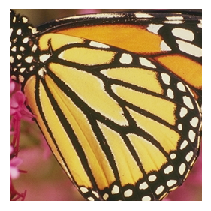

In [33]:
x = dinv.utils.load_example("butterfly.png", device=device)
dinv.utils.plot(x)

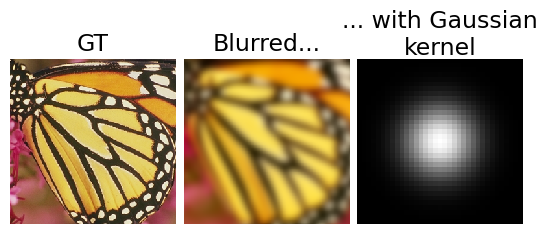

In [34]:
# Blur with Gaussian filter parameter
filter = dinv.physics.blur.gaussian_blur((5, 5))

physics = dinv.physics.Blur(filter=filter, device=device)

# Simulate measurements
y = physics(x)

# Display
dinv.utils.plot(
    {
        "GT": x,
        "Blurred...": y,
        "... with Gaussian kernel": filter,
    }
)

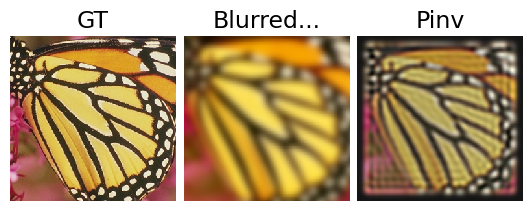

In [35]:
# Inverse
x_pinv = physics.A_dagger(y)

dinv.utils.plot(
    {
        "GT": x,
        "Blurred...": y,
        "Pinv": x_pinv,
    }
)

In [37]:
from pylops import TorchOperator

class DeepInvOperator(dinv.physics.LinearPhysics):
    def __init__(self, Op, **kwargs):
        super().__init__(**kwargs)
        self.Op = TorchOperator(Op, batch=True, )

    def A(
        self, x: torch.Tensor, **kwargs
    ) -> torch.Tensor:
        """Forward operator.

        :param torch.Tensor x: input image with 3 color (RGB) channels, i.e. [*,3,*,*]
        :param dict kwargs: any other keyword parameters to set on the fly, such as noise model sigma
        :return: torch.Tensor grayscale measurements
        """
        super().update_parameters(**kwargs)
        
        y = self.Op(x.reshape(x.shape[0], -1)).reshape(x.shape)
        return y
    

class DeepInvOperator(dinv.physics.LinearPhysics):
    def __init__(self, Op, **kwargs):
        super().__init__(**kwargs)
        self.Op = TorchOperator(Op, batch=True, )

    def A(
        self, x: torch.Tensor, **kwargs
    ) -> torch.Tensor:
        """Forward operator.

        :param torch.Tensor x: input image with 3 color (RGB) channels, i.e. [*,3,*,*]
        :param dict kwargs: any other keyword parameters to set on the fly, such as noise model sigma
        :return: torch.Tensor grayscale measurements
        """
        super().update_parameters(**kwargs)
        
        x = x.numpy()
        y = torch.from_numpy(self.Op.matvec(x.reshape(x.shape[0], -1)).reshape(x.shape))
        return y
    
    def A_adjoint(
        self, y: torch.Tensor, **kwargs
    ) -> torch.Tensor:
        """Closed-form adjoint operator.

        :param torch.Tensor y: input grayscale measurements
        :param dict kwargs: any other keyword parameters to set on the fly, such as noise model sigma
        :return: torch.Tensor adjoint reconstruction
        """
        super().update_parameters(**kwargs)

        y = y.numpy()
        x = torch.from_numpy(self.Op.rmatvec(y.reshape(y.shape[0], -1)).reshape(y.shape))
        return x


In [38]:
h = physics.filter[0, 0].cpu().numpy()
POp = Convolve2D(x.shape[2:], h=h, offset=(h.shape[0]//2, h.shape[1]//2))

TOp = TorchOperator(BlockDiag([POp, POp, POp]), batch=False, )
TOp(x[0, :])

TOp = TorchOperator(BlockDiag([POp, POp, POp]), batch=True, )
TOp(x.reshape(x.shape[0], -1))

tensor([[0.0837, 0.0988, 0.1145,  ..., 0.1116, 0.0991, 0.0861]],
       dtype=torch.float64)

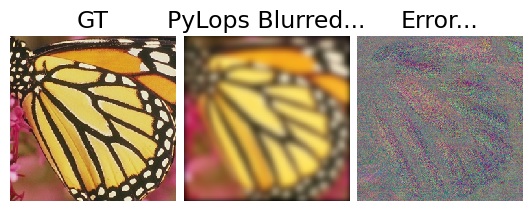

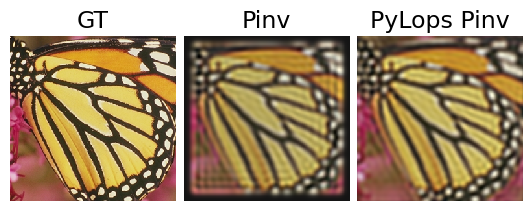

In [40]:
h = physics.filter[0, 0].cpu().numpy()
POp = Convolve2D(x.shape[2:], h=h, offset=(h.shape[0]//2, h.shape[1]//2))

Pphysics = DeepInvOperator(BlockDiag([POp, POp, POp]), img_size=x.shape[2:])

# Simulate measurements
ypylops = Pphysics(x)

# Display
dinv.utils.plot(
    {
        "GT": x,
        "PyLops Blurred...": ypylops,
        "Error...": y - ypylops[:, :, h.shape[0]//2:-h.shape[0]//2+1, h.shape[1]//2:-h.shape[1]//2+1]
    }
)

# Inverse
x_inv = physics.A_dagger(y)
xpylops_inv = Pphysics.A_dagger(ypylops)

dinv.utils.plot(
    {
        "GT": x,
        "Pinv": x_inv,
        "PyLops Pinv": xpylops_inv,
    }
)

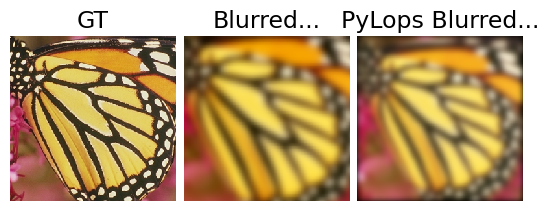

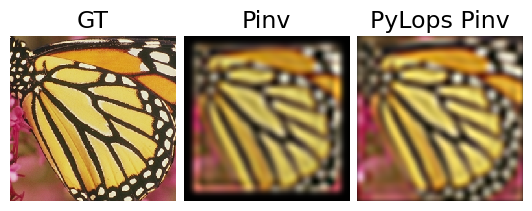

In [42]:
# With multiple samples

# Simulate measurements
x1 = torch.concat([x, x], dim=0)
y1 = physics(x1)
y1pylops = Pphysics(x1)

# Display
dinv.utils.plot(
    {
        "GT": x,
        "Blurred...": y1[1],
        "PyLops Blurred...": y1pylops[1],
    }
)

# Inverse
x1_inv = physics.A_dagger(y1, max_iter=5)
x1pylops_inv = Pphysics.A_dagger(y1pylops, max_iter=5)

dinv.utils.plot(
    {
        "GT": x,
        "Pinv": x1_inv[1],
        "PyLops Pinv": x1pylops_inv[1],
    }
)

In [1]:
0.4472 * 0.66851, 0.8781 * 0.66851, 0.1706 * 0.66851

(0.298957672, 0.5870186310000001, 0.11404780600000002)

In [5]:
import numpy as np
from pylops.signalprocessing.decolorize import Decolorize

Dop = Decolorize((32, 64))

x = np.ones((3, 32, 64))

y = Dop @ x
xadj = Dop.H @ y

(3, np.int64(32), np.int64(64)) (np.int64(32), np.int64(64))


(3, np.int64(170), np.int64(257)) (np.int64(170), np.int64(257))


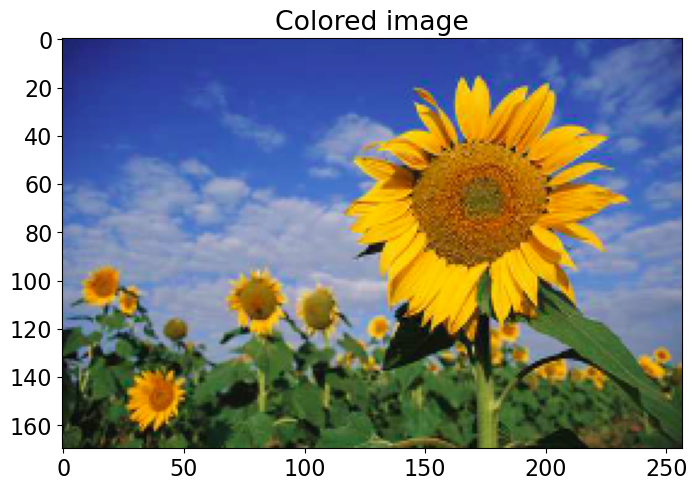

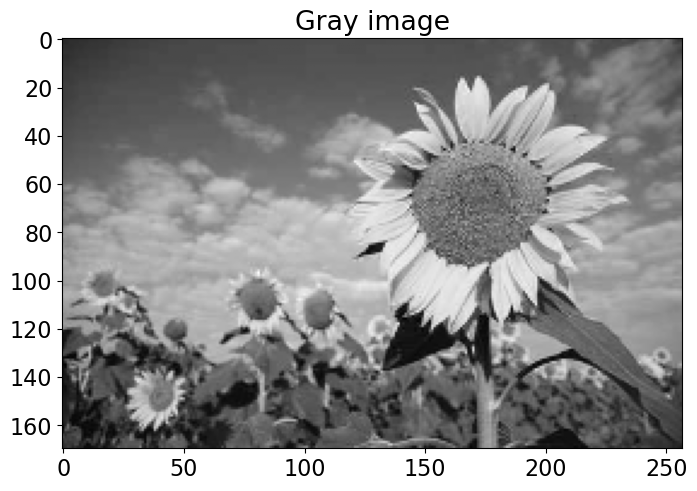

In [9]:
im = plt.imread('../data/sunflower.png')
im = im[::2, ::2, :3]
ny, nx, _ = im.shape

plt.figure()
plt.imshow(im)
plt.title('Colored image')

Dop = Decolorize((ny, nx))
img_gray = Dop * im.transpose(2, 0, 1)

plt.figure()
plt.imshow(img_gray, cmap="gray")
plt.title('Gray image');


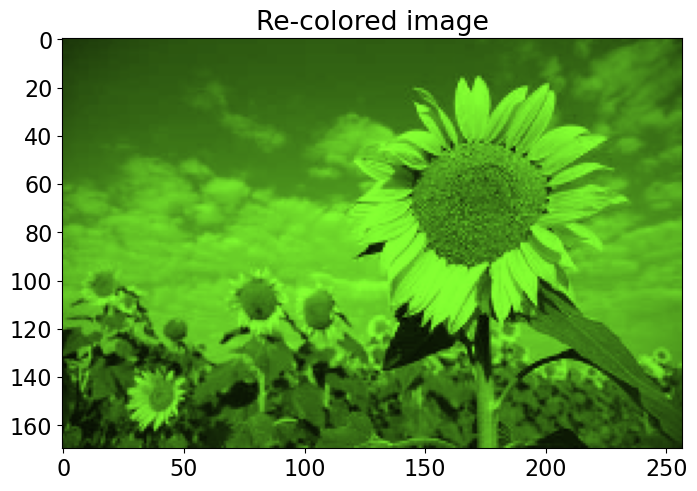

In [24]:
# Colorize by inversion
img_recol = Dop.div(img_gray.ravel(), niter=10)
img_recol = img_recol.reshape(3, ny, nx)

plt.figure()
plt.imshow(img_recol.transpose(1, 2, 0))
plt.title('Re-colored image');

In [29]:
Dop @ img_recol - Dop @ im.transpose(2, 0, 1)

array([[1.38777878e-16, 1.66533454e-16, 1.94289029e-16, ...,
        2.49800181e-16, 1.94289029e-16, 2.49800181e-16],
       [1.38777878e-16, 1.66533454e-16, 1.94289029e-16, ...,
        3.05311332e-16, 1.94289029e-16, 2.49800181e-16],
       [1.38777878e-16, 1.66533454e-16, 1.94289029e-16, ...,
        2.77555756e-16, 2.22044605e-16, 2.22044605e-16],
       ...,
       [1.94289029e-16, 2.49800181e-16, 2.22044605e-16, ...,
        1.66533454e-16, 2.22044605e-16, 1.94289029e-16],
       [1.94289029e-16, 1.94289029e-16, 2.22044605e-16, ...,
        1.66533454e-16, 1.66533454e-16, 1.66533454e-16],
       [1.66533454e-16, 2.22044605e-16, 2.49800181e-16, ...,
        1.66533454e-16, 1.38777878e-16, 1.11022302e-16]], shape=(170, 257))